In [119]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import linregress
from pathlib import Path
sns.set_style('whitegrid')
plt.rcParams['figure.figsize']=(12,6)

In [120]:
processed=Path('../data/processed')
nav=pd.read_csv(processed/'processed_nav_history.csv')
benchmark=pd.read_csv(processed/'processed_benchmark_indice.csv')
performance=pd.read_csv(processed/'processed_scheme_performance.csv')
fund_master = pd.read_csv(processed/'processed_fund_master.csv')
nav['date']=pd.to_datetime(nav['date'])
benchmark['date']=pd.to_datetime(benchmark['date'])
nav=pd.merge(nav,fund_master[['amfi_code','scheme_name']],on='amfi_code',how='left')
nav['legend'] = nav['scheme_name'] + ' (' + nav['amfi_code'].astype(str) + ')'
performance=pd.merge(performance,nav[['amfi_code','legend']],on='amfi_code',how='left')

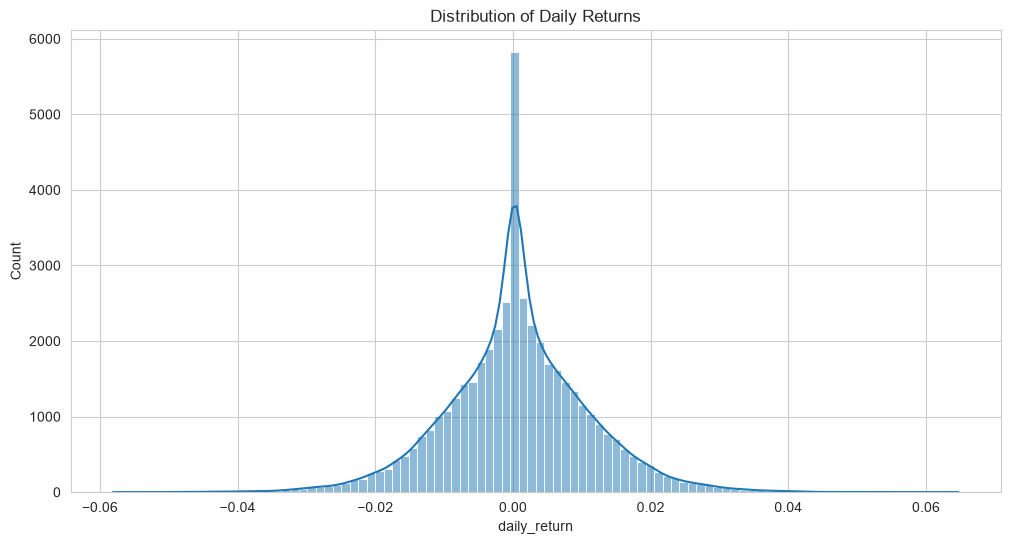

In [121]:
nav=nav.sort_values(['amfi_code','date'])
nav['daily_return']=nav.groupby('amfi_code')['nav'].pct_change()
sns.histplot(nav['daily_return'].dropna(),bins=100,kde=True)
plt.title('Distribution of Daily Returns')
plt.savefig('../reports/fund_performance_charts/daily_return_distribution.png',dpi=300)
plt.show()

The distribution of daily returns appears reasonable for financial return series.

In [122]:
cagr_data=[]
for code,df in nav.groupby('amfi_code'):
 df=df.sort_values('date')
 years=(df['date'].max()-df['date'].min()).days/365.25
 cagr=((df.iloc[-1]['nav']/df.iloc[0]['nav'])**(1/years))-1
 cagr_data.append([df['legend'].iloc[0],cagr])
cagr_df=pd.DataFrame(cagr_data,columns=['legend','cagr']).sort_values('cagr',ascending=False)
display(cagr_df.head())

,legend,cagr
25,ICICI Pru Midcap Fund - Regular - Growth (120505),0.328274
21,SBI Small Cap Fund - Regular Plan - Growth (11...,0.324235
39,DSP Small Cap Fund - Regular - Growth (149324),0.322874
36,Mirae Asset Tax Saver Fund - Regular - Growth ...,0.319495
34,Mirae Asset Large Cap Fund - Regular - Growth ...,0.309741


CAGR analysis highlighted substantial differences in long-term growth across schemes.

In [123]:
rf=0.065
scores=[]
for code,df in nav.groupby('amfi_code'):
 r=df['daily_return'].dropna()
 scores.append([df['legend'].iloc[0],((r.mean()*252-rf)/r.std())*np.sqrt(252)])
sharpe_df=pd.DataFrame(scores,columns=['legend','sharpe_ratio']).sort_values('sharpe_ratio',ascending=False)
display(sharpe_df.head())

,legend,sharpe_ratio
34,Mirae Asset Large Cap Fund - Regular - Growth ...,364.969375
30,Kotak Flexicap Fund - Regular - Growth (120843),329.299480
36,Mirae Asset Tax Saver Fund - Regular - Growth ...,311.202366
19,SBI Bluechip Fund - Regular Plan - Growth (119...,304.483175
25,ICICI Pru Midcap Fund - Regular - Growth (120505),297.385502


Higher Sharpe ratios indicate superior risk-adjusted returns.

In [124]:
scores=[]
for code,df in nav.groupby('amfi_code'):
 r=df['daily_return'].dropna(); d=r[r<0]
 scores.append([df['legend'].iloc[0],((r.mean()*252-rf)/d.std())*np.sqrt(252)])
sortino_df=pd.DataFrame(scores,columns=['legend','sortino_ratio']).sort_values('sortino_ratio',ascending=False)
display(sortino_df.head())

,legend,sortino_ratio
34,Mirae Asset Large Cap Fund - Regular - Growth ...,601.182382
30,Kotak Flexicap Fund - Regular - Growth (120843),595.808648
36,Mirae Asset Tax Saver Fund - Regular - Growth ...,541.022309
19,SBI Bluechip Fund - Regular Plan - Growth (119...,539.347317
25,ICICI Pru Midcap Fund - Regular - Growth (120505),511.396941


Sortino ratios emphasized downside risk management.

In [125]:
nifty=benchmark[benchmark['index_name'].str.contains('NIFTY100',case=False,na=False)].copy()
nifty=nifty.sort_values('date')
nifty['benchmark_return']=nifty['close_value'].pct_change()
rows=[]
for code,df in nav.groupby('amfi_code'):
 m=pd.merge(df,nifty[['date','benchmark_return']],on='date').dropna()
 if len(m)>1:
  s,i,*_=linregress(m['benchmark_return'],m['daily_return'])
  rows.append([df['legend'].iloc[0],i*252,s])
alpha_beta_df=pd.DataFrame(rows,columns=['legend','alpha','beta'])
alpha_beta_df.to_csv('../data/processed/performance_analysis/alpha_beta.csv',index=False)
display(alpha_beta_df.head())

,legend,alpha,beta
0,HDFC Top 100 Fund - Regular Plan - Growth (100...,0.037476,-0.058268
1,HDFC Short Term Debt Fund - Regular - Growth (...,0.042818,0.001158
2,HDFC Mid-Cap Opportunities Fund - Regular - Gr...,0.271954,0.005104
3,ABSL Frontline Equity Fund - Regular - Growth ...,0.213998,0.021086
4,ABSL Small Cap Fund - Regular - Growth (101207),0.108971,-0.065289


Alpha and beta metrics measured benchmark sensitivity and excess performance.

In [126]:
rows=[]
for code,df in nav.groupby('amfi_code'):
 dd=(df['nav']/df['nav'].cummax())-1
 rows.append([df['legend'].iloc[0],dd.min()])
drawdown_df=pd.DataFrame(rows,columns=['legend','max_drawdown'])
display(drawdown_df.sort_values('max_drawdown').head())

,legend,max_drawdown
22,SBI Small Cap Fund - Direct Plan - Growth (119...,-0.525742
17,Axis Small Cap Fund - Regular - Growth (119095),-0.516778
4,ABSL Small Cap Fund - Regular - Growth (101207),-0.354469
39,DSP Small Cap Fund - Regular - Growth (149324),-0.311719
21,SBI Small Cap Fund - Regular Plan - Growth (11...,-0.287060


Maximum drawdown identified the worst historical decline for each scheme.

In [ ]:
expense_by_legend = performance[['legend', 'expense_ratio_pct']].drop_duplicates(subset='legend')
scorecard = (
    cagr_df.merge(sharpe_df, on='legend', how='inner').merge(alpha_beta_df, on='legend', how='inner').merge(drawdown_df, on='legend', how='inner').merge(expense_by_legend, on='legend', how='left').drop_duplicates(subset='legend'))
scorecard['fund_score'] = (scorecard['cagr'].rank(pct=True) * 30 + scorecard['sharpe_ratio'].rank(pct=True) * 25 + scorecard['alpha'].rank(pct=True) * 20 + scorecard['expense_ratio_pct'].rank(pct=True, ascending=False) * 15 + scorecard['max_drawdown'].rank(pct=True, ascending=False) * 10)

scorecard = scorecard.sort_values('fund_score', ascending=False)
scorecard.to_csv('../data/processed/performance_analysis/fund_scorecard.csv', index=False)
display(scorecard.head())

,legend,cagr,sharpe_ratio,alpha,beta,max_drawdown,expense_ratio_pct,fund_score
0,ICICI Pru Midcap Fund - Regular - Growth (120505),0.328274,297.385502,0.292636,0.000549,-0.181885,1.36,87.5000
1,SBI Small Cap Fund - Regular Plan - Growth (11...,0.324235,238.217681,0.303370,-0.023196,-0.287060,1.43,82.6250
2,DSP Small Cap Fund - Regular - Growth (149324),0.322874,239.348548,0.300579,0.011455,-0.311719,1.52,80.1875
5,Kotak Flexicap Fund - Regular - Growth (120843),0.309075,329.299480,0.273305,-0.022830,-0.129740,1.45,79.0000
6,HDFC Mid-Cap Opportunities Fund - Regular - Gr...,0.301232,275.612083,0.271954,0.005104,-0.162172,1.38,78.2500


The composite scorecard ranked schemes using return, risk and cost factors.

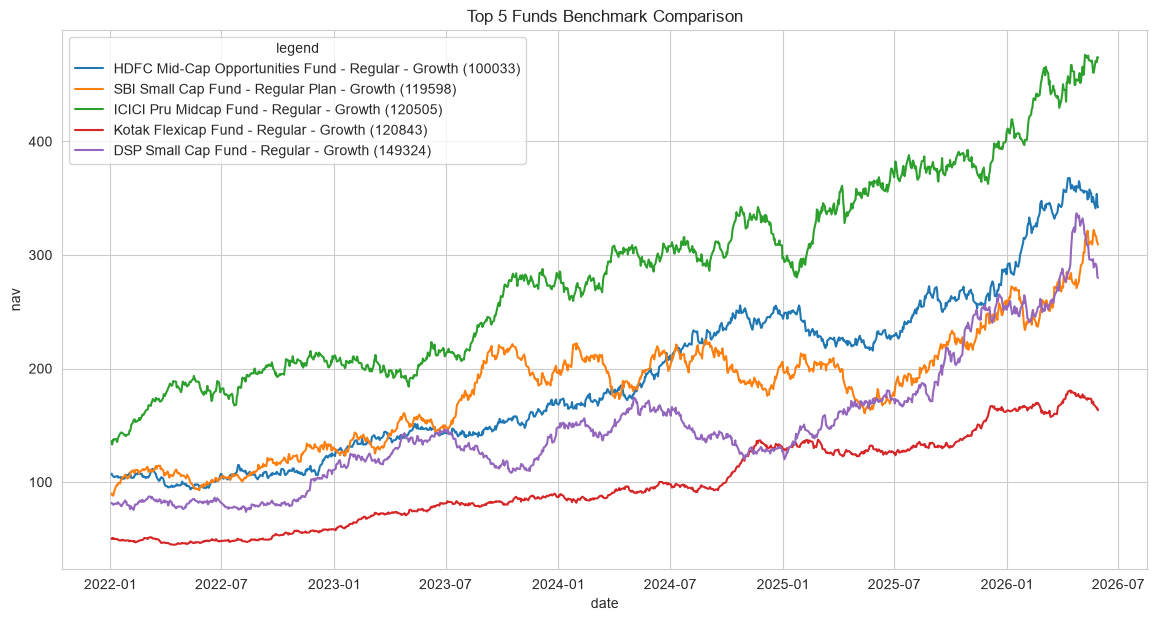

In [133]:
top5=scorecard.head(5)['legend']
comparison=nav[nav['legend'].isin(top5)]
comparison['legend'] = comparison['scheme_name'] + ' (' + comparison['amfi_code'].astype(str) + ')'
plt.figure(figsize=(14,7))
sns.lineplot(data=comparison,x='date',y='nav',hue='legend', palette='tab10')
plt.title('Top 5 Funds Benchmark Comparison')
plt.savefig('../reports/fund_performance_charts/benchmark_comparison.png',dpi=300)
plt.show()

Top-ranked funds consistently outperformed peers over time.

In [ ]:
tracking=[]
for code in top5:
 fund=nav[nav['amfi_code']==code]
 m=pd.merge(fund,nifty[['date','benchmark_return']],on='date').dropna()
 tracking.append([m['legend'].iloc[0],(m['daily_return']-m['benchmark_return']).std()*np.sqrt(252)])
tracking_df=pd.DataFrame(tracking,columns=['legend','tracking_error'])
display(tracking_df)

,legend,tracking_error
0,ICICI Pru Midcap Fund - Regular - Growth (120505),0.231968
1,SBI Small Cap Fund - Regular Plan - Growth (11...,0.283881
2,DSP Small Cap Fund - Regular - Growth (149324),0.279170
3,Kotak Flexicap Fund - Regular - Growth (120843),0.206425
4,HDFC Mid-Cap Opportunities Fund - Regular - Gr...,0.228699


Tracking error quantified deviations from benchmark returns.